In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Basic Exploration

In [2]:
df=pd.read_csv('/Users/amankumar/Desktop/DataSet_project/Superstore Sales Analysis/train.csv')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Check the number of rows and columns in the dataset
df.shape

(9800, 18)

In [5]:
# Check for missing values in each column
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
# Find the total number of unique customers
df['Customer ID'].nunique()

793

In [7]:
# Find the number of unique categories and sub-categories
df[['Customer ID','Sub-Category']].nunique()

Customer ID     793
Sub-Category     17
dtype: int64

In [8]:
# Check the data type of the date columns
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

### Data Cleaning


In [9]:
# Convert Order Date and Ship Date columns to datetime format
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date']= pd.to_datetime(df['Ship Date'],dayfirst=True)
df['Order Date']
df['Ship Date']

0      2017-11-11
1      2017-11-11
2      2017-06-16
3      2016-10-18
4      2016-10-18
          ...    
9795   2017-05-28
9796   2016-01-17
9797   2016-01-17
9798   2016-01-17
9799   2016-01-17
Name: Ship Date, Length: 9800, dtype: datetime64[us]

In [10]:
# Create a new column for Order Month from Order Date
df['Order Month']=df['Order Date'].dt.month
df['Order Month']

0       11
1       11
2        6
3       10
4       10
        ..
9795     5
9796     1
9797     1
9798     1
9799     1
Name: Order Month, Length: 9800, dtype: int32

In [11]:
# Create a new column for Order Year from Order Date
df['Order year']=df['Order Date'].dt.year
df['Order year']

0       2017
1       2017
2       2017
3       2016
4       2016
        ... 
9795    2017
9796    2016
9797    2016
9798    2016
9799    2016
Name: Order year, Length: 9800, dtype: int32

In [12]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [13]:
# Create a new column to calculate the number of days taken to ship each order
df['Shiping Date']=(df['Ship Date'] -df['Order Date']).dt.days
df['Shiping Date']

0       3
1       3
2       4
3       7
4       7
       ..
9795    7
9796    5
9797    5
9798    5
9799    5
Name: Shiping Date, Length: 9800, dtype: int64

### Basic Calculations

In [14]:
# Calculate the total sales of the dataset
df['Sales'].sum()

np.float64(2261536.7827)

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Order year,Shiping Date
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,2017,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,2016,7


In [16]:
# Calculate the average sales per order
df['Sales'].mean()

np.float64(230.76905945918367)

In [17]:
# Find the highest sales value in a single transaction
df['Sales'].max()

np.float64(22638.48)

In [18]:
# Find the lowest sales value in a single transaction
df['Sales'].min()

np.float64(0.444)

In [19]:
# Calculate the total number of sales transactions
df['Sales'].count()

np.int64(9800)

In [20]:
# Calculate the average number of days taken to ship an order
df['Shiping Date'].mean()

np.float64(3.9611224489795918)

### Region & Category Analysis

In [21]:
# Calculate total sales for each region
df.groupby('Region')['Sales'].sum()

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

In [22]:
# Find the region with the highest total sales
df.groupby('Region')['Sales'].sum().idxmax()

'West'

In [23]:
df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

In [24]:
# Calculate total sales for each category
df.groupby('Category')['Sales'].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

In [25]:
# Find the category with the highest total sales
df.groupby('Category')['Sales'].sum().idxmax()

'Technology'

In [26]:
# Calculate total sales for each sub-category
df.groupby('Sub-Category')['Sales'].sum()

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64

In [27]:
# Find the sub-category with the highest total sales
df.groupby('Sub-Category')['Sales'].sum().idxmax()

'Phones'

In [28]:
# Calculate average sales for each category
df.groupby('Category')['Sales'].mean()

Category
Furniture          350.653790
Office Supplies    119.381001
Technology         456.401474
Name: Sales, dtype: float64

In [29]:
# Find the top 5 customers based on total sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

In [30]:
# Find the top 5 cities based on total sales
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(5)

City
New York City    252462.547
Los Angeles      173420.181
Seattle          116106.322
San Francisco    109041.120
Philadelphia     108841.749
Name: Sales, dtype: float64

### Time-Based Analysis

In [31]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Order year,Shiping Date
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,2017,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,2016,7


In [32]:
# Calculate total sales for each month
df.groupby('Order Month')['Sales'].sum()

Order Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

In [33]:
# Calculate total sales for each year
df.groupby('Order year')['Sales'].sum() 

Order year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

In [34]:
# Find the month with the highest total sales
df.groupby('Order Month')['Sales'].sum().sort_values(ascending=False).idxmax()

np.int32(11)

In [35]:
# Find the year with the highest total sales
df.groupby('Order year')['Sales'].sum().idxmax()

np.int32(2018)

### Customer & Shipping Analysis

In [36]:
# Find the top 5 customers based on total sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

In [37]:
# Calculate the number of orders placed by each customer
df.groupby('Customer Name')['Order ID'].count()

Customer Name
Aaron Bergman          6
Aaron Hawkins         11
Aaron Smayling        10
Adam Bellavance       18
Adam Hart             20
                      ..
Xylona Preis          28
Yana Sorensen         12
Yoseph Carroll         8
Zuschuss Carroll      31
Zuschuss Donatelli     9
Name: Order ID, Length: 793, dtype: int64

In [38]:
# Find the customer with the highest number of orders
df.groupby('Customer Name')['Order ID'].nunique().idxmax()

'Emily Phan'

In [39]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Order year,Shiping Date
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,2017,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,2016,7


In [40]:
# Calculate the average shipping time for each ship mode
df['Shipping Time']=(df['Ship Date'] - df['Order Date']).dt.days
df.groupby('Ship Mode')['Shipping Time'].mean()

Ship Mode
First Class       2.179214
Same Day          0.044610
Second Class      3.249211
Standard Class    5.008363
Name: Shipping Time, dtype: float64

In [41]:
# Compare the number of orders across different ship modes
df.groupby('Ship Mode')['Order ID'].nunique()

Ship Mode
First Class        772
Same Day           261
Second Class       944
Standard Class    2945
Name: Order ID, dtype: int64

### Visualization

<Axes: xlabel='Region'>

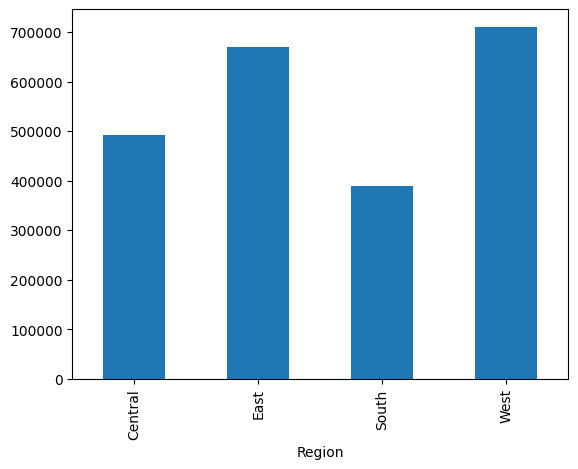

In [42]:
# Create a bar chart to compare total sales across regions
df.groupby('Region')['Sales'].sum().plot(kind='bar')

<Axes: xlabel='Category'>

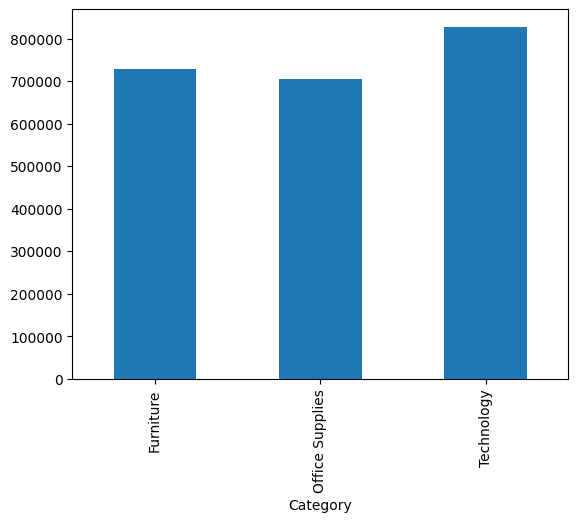

In [43]:
# Create a bar chart to compare total sales across categories
df.groupby('Category')['Sales'].sum().plot(kind='bar')


<Axes: xlabel='Sub-Category'>

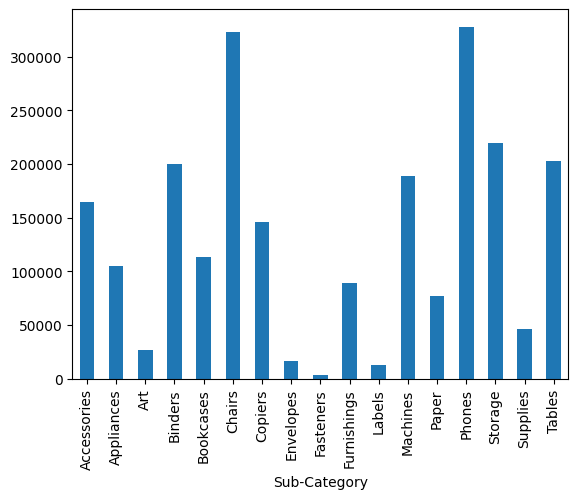

In [44]:
# Create a bar chart to compare total sales across sub-categories
df.groupby('Sub-Category')['Sales'].sum().plot(kind='bar')

<Axes: xlabel='Order Month'>

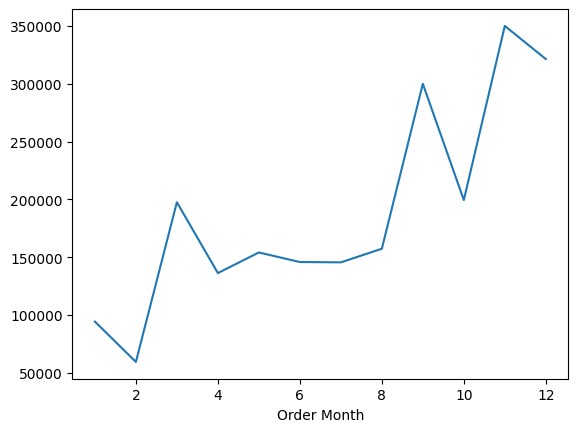

In [45]:
# Create a line chart to show the monthly sales trend
df.groupby('Order Month')['Sales'].sum().plot(kind='line')

<Axes: xlabel='Order year'>

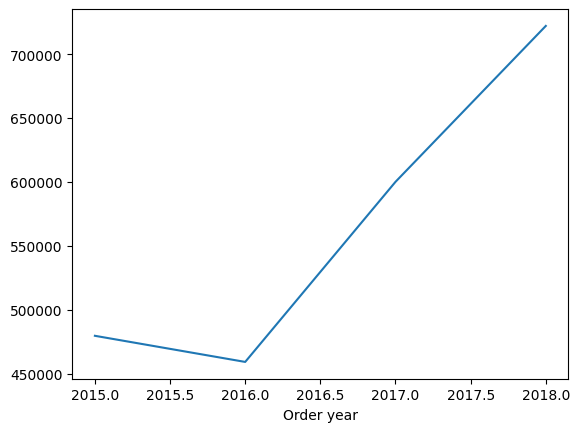

In [46]:
# Create a line chart to compare yearly sales
df.groupby('Order year')['Sales'].sum().plot(kind='line')

<Axes: ylabel='Frequency'>

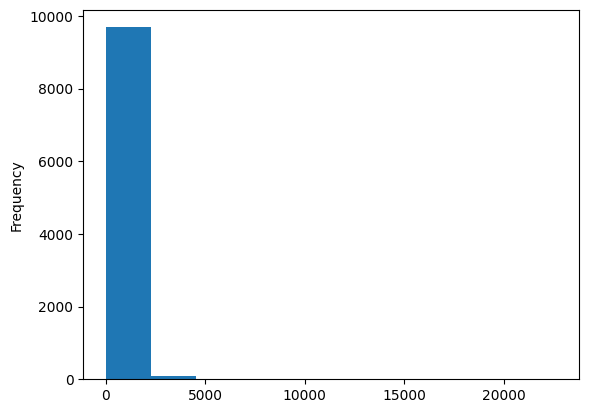

In [47]:
# Create a histogram to visualize the distribution of sales
df['Sales'].plot(kind='hist')

In [66]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Order year,Shiping Date,Shipping Time
8176,8177,CA-2017-135965,2017-09-22,2017-09-25,First Class,SZ-20035,Sam Zeldin,Home Office,United States,New York City,...,East,OFF-ST-10002370,Office Supplies,Storage,Sortfiler Multipurpose Personal File Organizer...,128.340,9,2017,3,3
1493,1494,CA-2018-139661,2018-10-30,2018-11-03,Standard Class,JW-15220,Jane Waco,Corporate,United States,Vancouver,...,West,FUR-FU-10002885,Furniture,Furnishings,Magna Visual Magnetic Picture Hangers,9.640,10,2018,4,4
8881,8882,CA-2017-135594,2017-06-30,2017-07-03,Second Class,AH-10120,Adrian Hane,Home Office,United States,Aurora,...,Central,TEC-AC-10003038,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,50.120,6,2017,3,3
2746,2747,CA-2015-155887,2015-05-12,2015-05-17,Standard Class,KT-16480,Kean Thornton,Consumer,United States,Franklin,...,East,FUR-TA-10002228,Furniture,Tables,"Bevis Traditional Conference Table Top, Plinth...",700.056,5,2015,5,5
6362,6363,CA-2018-110443,2018-11-21,2018-11-25,Standard Class,CK-12205,Chloris Kastensmidt,Consumer,United States,Renton,...,West,OFF-BI-10001670,Office Supplies,Binders,Vinyl Sectional Post Binders,150.800,11,2018,4,4


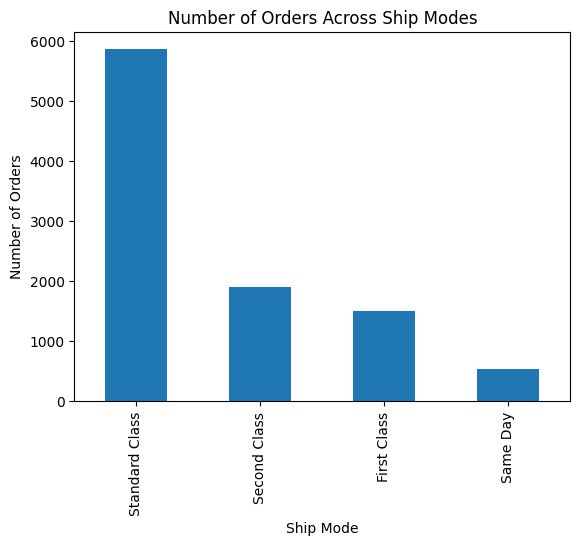

In [71]:
# Create a bar chart to compare the number of orders across different ship modes
df['Ship Mode'].value_counts().plot(kind='bar')
plt.title('Number of Orders Across Ship Modes')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.show()

Text(0, 0.5, 'Number of Orders')

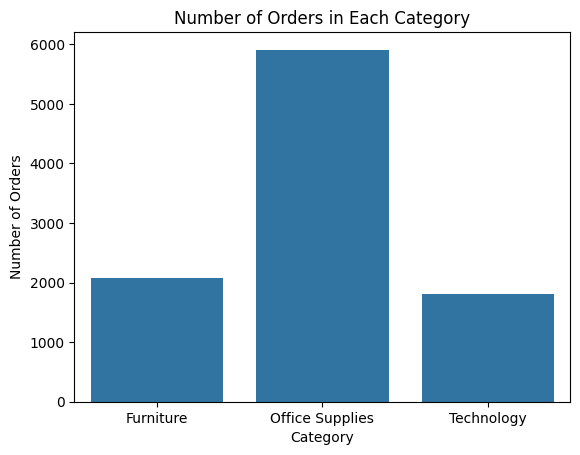

In [72]:
# Create a countplot to show the number of orders in each category
sns.countplot(x='Category', data=df)

plt.title('Number of Orders in Each Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')

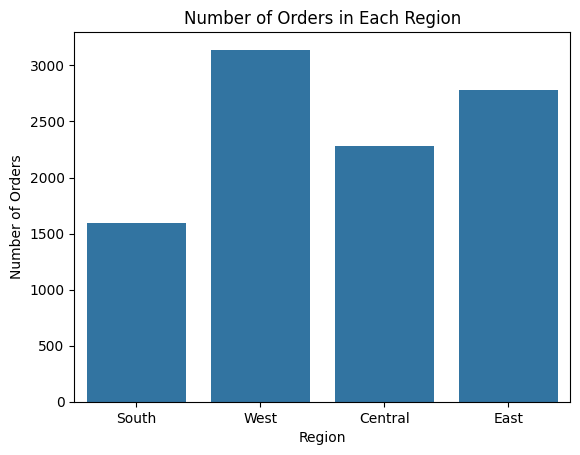

In [73]:
# Create a countplot to show the number of orders in each region
sns.countplot(x='Region', data=df)
plt.title('Number of Orders in Each Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.show()

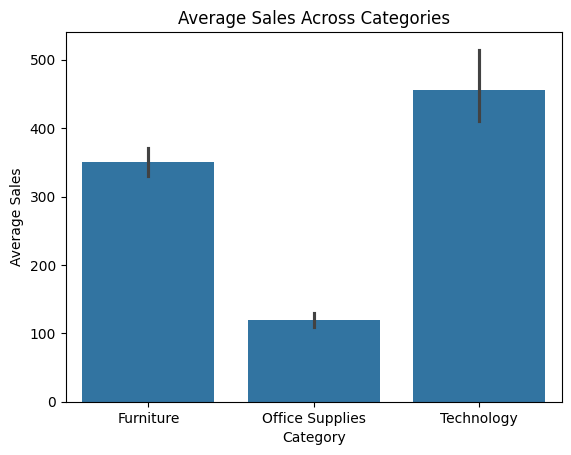

In [86]:
# Create a barplot to compare average sales across categories
sns.barplot(x='Category', y='Sales', data=df)
plt.title('Average Sales Across Categories')
plt.xlabel('Category')
plt.ylabel('Average Sales')
plt.show()

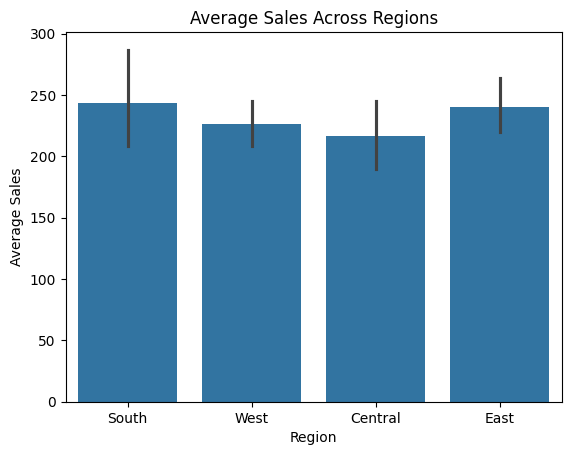

In [87]:
# Create a barplot to compare average sales across regions
sns.barplot(x='Region', y='Sales', data=df)
plt.title('Average Sales Across Regions')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.show()

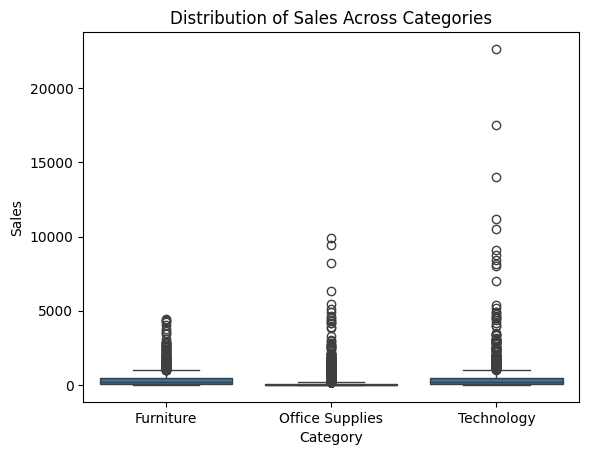

In [88]:
# Create a boxplot to visualize the distribution of sales across categories
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Distribution of Sales Across Categories')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

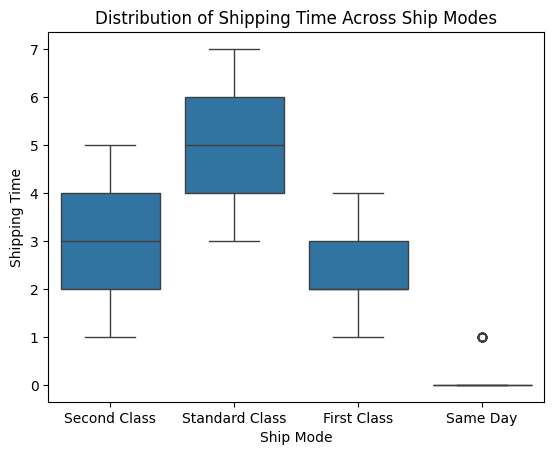

In [84]:
# Create a boxplot to visualize the distribution of shipping time across ship modes
sns.boxplot(x='Ship Mode', y='Shipping Time', data=df)
plt.title('Distribution of Shipping Time Across Ship Modes')
plt.xlabel('Ship Mode')
plt.ylabel('Shipping Time')
plt.show()

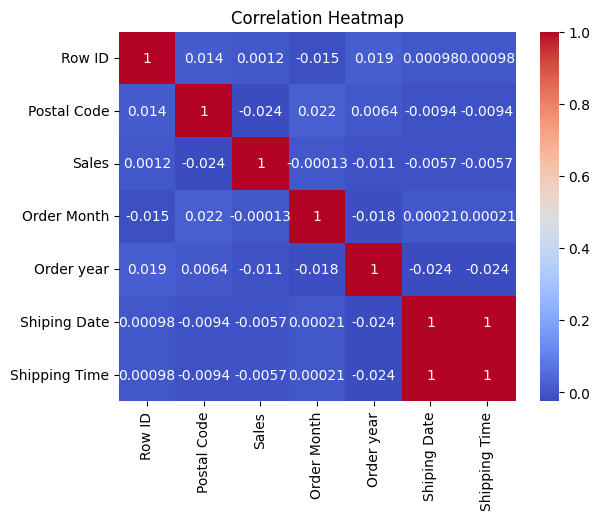

In [83]:
# Create a heatmap to visualize correlations between numerical columns
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

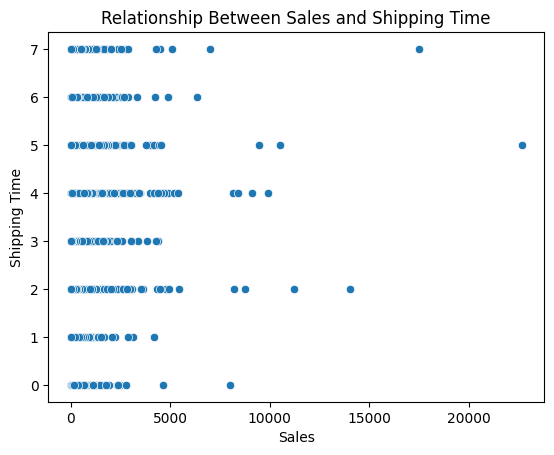

In [82]:
# Create a scatterplot to visualize the relationship between Sales and Shipping Time
sns.scatterplot(x='Sales', y='Shipping Time', data=df)

plt.title('Relationship Between Sales and Shipping Time')
plt.xlabel('Sales')
plt.ylabel('Shipping Time')

plt.show()

### Final Insights

In [81]:
# Identify the region with the highest total sales
df.groupby('Region')['Sales'].sum().idxmax()

'West'

In [80]:
# Identify the category with the highest total sales
df.groupby('Category')['Sales'].sum().idxmax()

'Technology'

In [79]:
# Identify the sub-category with the highest total sales
df.groupby('Sub-Category')['Sales'].sum().idxmax()

'Phones'

In [78]:
# Identify the top customer based on total sales
df.groupby('Customer Name')['Sales'].sum().idxmax()

'Sean Miller'

In [77]:
# Identify the year with the highest total sales
df.groupby('Order year')['Sales'].sum().idxmax()

np.int32(2018)

In [76]:
# Identify the month with the highest total sales
df.groupby('Order Month')['Sales'].sum().idxmax()


np.int32(11)

In [75]:
# Compare different ship modes based on shipping time
df.groupby('Ship Mode')['Shipping Time'].mean()

Ship Mode
First Class       2.179214
Same Day          0.044610
Second Class      3.249211
Standard Class    5.008363
Name: Shipping Time, dtype: float64

In [74]:
# Write 4-5 key insights based on the analysis
# Key Insights

print("1. Highest Sales Region:", df.groupby('Region')['Sales'].sum().idxmax())

print("2. Highest Sales Category:", df.groupby('Category')['Sales'].sum().idxmax())

print("3. Highest Sales Sub-Category:", df.groupby('Sub-Category')['Sales'].sum().idxmax())

print("4. Top Customer by Sales:", df.groupby('Customer Name')['Sales'].sum().idxmax())

print("5. Highest Sales Year:", df.groupby('Order year')['Sales'].sum().idxmax())

1. Highest Sales Region: West
2. Highest Sales Category: Technology
3. Highest Sales Sub-Category: Phones
4. Top Customer by Sales: Sean Miller
5. Highest Sales Year: 2018
